# Lab: Comparing Distributions Across Groups

New York City residents can use 311 to report potholes, cave-ins, failed street repairs, and other street conditions. Comparing the daily volume of these requests can help a city describe where reported demand for street-condition services was greatest.

Use the reproducible analysis workflow:

1. **Question**
2. **Data**
3. **Operation**
4. **Check**
5. **Evidence**
6. **Conclusion**
7. **Limitation**


## Learning goals

- use Pandas datetime and string methods to prepare categories;
- use `groupby()`, `.size()`, and `reset_index()` to create daily counts;
- summarize a quantitative feature within groups;
- compare distributions with histograms, box plots, and violin plots;
- interpret center, spread, shape, overlap, and unusual values; and
- distinguish reported request volume from the underlying number of street problems.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response against the notebook output.

At the end, disclose whether you used AI. If you did, describe one suggestion you evaluated and what you accepted, modified, or rejected. If you did not, state that clearly.


## Dataset

The dataset was prepared from NYC Open Data's [*311 Service Requests from 2020 to Present*](https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2020-to-Present/erm2-nwe9). It contains 70,198 requests created during 2025 with the complaint type `Street Condition`. Rows assigned to an unspecified borough were excluded, and the four features below were retained. Each row represents one service request, not one unique street problem.

| Feature | Description |
| --- | --- |
| `request_id` | Identifier assigned to the 311 service request |
| `created_date` | Date and time when 311 created the request |
| `borough` | Borough assigned to the request |
| `descriptor` | More specific kind of street condition |

The dataset has no missing values in the retained features and was downloaded on August 13, 2026. Request counts may reflect borough population, street mileage, construction activity, awareness of 311, access to the service, and willingness to report. Therefore, borough comparisons describe **reported request volume**; they do not directly measure street quality or government performance.


# Guided analysis

## Step 1: Question

> **How did the daily number of reported street-condition requests differ across New York City's five boroughs in 2025?**


## Step 2: Data

### Import the libraries

Import Pandas, Matplotlib's `pyplot`, and Seaborn using their conventional aliases.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Read the data

Read `data/nyc_311_street_conditions_2025.csv` into a DataFrame named `requests`. Use `parse_dates=["created_date"]` so Pandas converts the CSV's text timestamps into datetime values while loading the file.


In [2]:
requests = pd.read_csv("data/nyc_311_street_conditions_2025.csv", parse_dates=["created_date"])


### Preview the data

Display the first and last five rows.


In [3]:
display(requests.head())
display(requests.tail())


,request_id,created_date,borough,descriptor
0,63575321,2025-01-01 02:27:33,BROOKLYN,Pothole
1,63585580,2025-01-01 02:31:08,QUEENS,Pothole
2,63590681,2025-01-01 02:39:44,BROOKLYN,Dumpster - Construction Waste
3,63580421,2025-01-01 02:55:52,QUEENS,Pothole
4,63605103,2025-01-01 04:20:00,BROOKLYN,Wear & Tear


,request_id,created_date,borough,descriptor
70193,67353473,2025-12-31 22:26:49,STATEN ISLAND,Pothole
70194,67346881,2025-12-31 22:27:34,STATEN ISLAND,Pothole
70195,67352385,2025-12-31 22:28:43,STATEN ISLAND,Cave-in
70196,67350032,2025-12-31 22:53:19,MANHATTAN,Defective Hardware
70197,67348685,2025-12-31 23:39:14,QUEENS,Pothole


### Inspect the DataFrame

Display its stored data types and missing-value counts.


In [4]:
requests.info()
requests.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 70198 entries, 0 to 70197
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   request_id    70198 non-null  int64         
 1   created_date  70198 non-null  datetime64[us]
 2   borough       70198 non-null  str           
 3   descriptor    70198 non-null  str           
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 2.1 MB


request_id      0
created_date    0
borough         0
descriptor      0
dtype: int64

**Complete the table using the data dictionary and your inspection results.** Classify each feature as categorical, quantitative, or temporal.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `request_id` | Categorical (identifier) | int64 | 0 |
| `created_date` | Temporal | datetime64[us] | 0 |
| `borough` | Categorical | str (object) | 0 |
| `descriptor` | Categorical | str (object) | 0 |


**What does one row represent?**

Your answer: One row represents a single 311 service request about a street condition. It is possible for the same underlying street problem (like one large pothole) to generate more than one row, since more than one resident can report it.


### Predict


**Which borough do you predict will have the greatest typical number of reported street-condition requests per day? What informed your prediction?**

Your answer: I predict Queens will have the greatest typical number of daily requests. Queens has a large land area and a large amount of street mileage compared to the other boroughs, and it is not as densely covered by public transit as Manhattan, which likely means more car traffic wearing down streets and more residents relying on drivable roads they'd want repaired.


## Step 3: Operation


### Make the borough names human-readable

The source stores borough names in all capital letters. **Title case** capitalizes the first letter of each word and writes the remaining letters in lowercase. For example, `STATEN ISLAND` becomes `Staten Island`.

Use `.str.title()` to convert every value in `requests["borough"]` to title case and save the result back into the same feature.


In [5]:
requests["borough"] = requests["borough"].str.title()


**What roles do `.str` and `.title()` play in this statement?**

Your answer: `.str` is Pandas' string accessor. It exposes vectorized string methods so we can apply a text operation to every value in the `borough` column at once instead of writing a loop. `.title()` is the specific string method being applied through that accessor; it converts each value to title case (capitalizing the first letter of each word and lowercasing the rest).


### Create a calendar date

Create `requests["date"]` with `requests["created_date"].dt.normalize()`. The `.dt` accessor opens Pandas' datetime tools, and `.normalize()` sets the time in every value to midnight while preserving its calendar date.


In [6]:
requests["date"] = requests["created_date"].dt.normalize()


### Count requests for each borough and date

Create a DataFrame named `daily_requests` with this sequence:

1. group `requests` by `date` and `borough`;
2. use `.size()` to count rows in every group; and
3. use `.reset_index(name="request_count")` to return a DataFrame whose count column is named `request_count`.

Display the first five rows.


In [7]:
daily_requests = (
    requests
    .groupby(["date", "borough"])
    .size()
    .reset_index(name="request_count")
)
daily_requests.head()


,date,borough,request_count
0,2025-01-01,Bronx,33
1,2025-01-01,Brooklyn,64
2,2025-01-01,Manhattan,14
3,2025-01-01,Queens,70
4,2025-01-01,Staten Island,8


**What does one row of `daily_requests` represent? How is that different from one row of `requests`?**

Your answer: One row of `daily_requests` represents the total number of street-condition requests made in one borough on one calendar date. This is different from `requests`, where one row represents a single individual service request. `daily_requests` is an aggregated summary; `requests` is the raw, request-level data.


**Why did we remove the time before grouping and counting the requests?** As a hint, try repeating the calculation with `created_date` in place of `date` and inspect the result.

Your answer: `created_date` includes the exact time down to the second, so almost every request has a unique timestamp. Grouping by `created_date` instead of `date` would put almost every request in its own group, producing counts of 1 (or very close to it) instead of a meaningful daily total. Normalizing to midnight collapses all requests from the same calendar day into one group so we can count how many requests happened per day, regardless of what time they were submitted.


### Set the borough order

Create `borough_order` containing the five borough names in alphabetical order.


In [8]:
borough_order = sorted(daily_requests["borough"].unique())
borough_order


['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']

### Calculate the mean daily request count

Create `borough_summary` by grouping `daily_requests` by `borough`, selecting `request_count`, calculating the mean, and using `.reindex(borough_order)`.


In [9]:
borough_summary = (
    daily_requests
    .groupby("borough")["request_count"]
    .mean()
    .reindex(borough_order)
)
borough_summary


borough
Bronx            19.060274
Brooklyn         50.345205
Manhattan        33.936986
Queens           71.180822
Staten Island    17.800000
Name: request_count, dtype: float64

**Why is comparing only these means incomplete?**

Your answer: The mean only summarizes the center of each borough's distribution. It doesn't show how spread out the daily counts are, whether the distribution is symmetric or skewed, whether there are unusually high or low days, or whether the distributions for different boroughs overlap. Two boroughs could have similar means but very different day-to-day variability, and the mean alone would hide that difference.


## Step 4: Check


### Check borough-date coverage

Count the number of rows for each borough in `daily_requests`, then use `.reindex(borough_order)`.


In [10]:
daily_requests.groupby("borough").size().reindex(borough_order)


borough
Bronx            365
Brooklyn         365
Manhattan        365
Queens           365
Staten Island    365
dtype: int64

**Does every borough have a count for all 365 dates?**

Your answer: Yes. Each borough has exactly 365 rows in `daily_requests`, one for every date in 2025.


**What would it mean if one or more boroughs had a count of fewer than 365 rows?**

Your answer: It would mean that borough had at least one date in 2025 with zero reported street-condition requests. Because `groupby().size()` only creates a row when there is at least one request to count, a day with no requests simply would not appear, rather than appearing as a row with a count of 0.


### Check the calculated data

Display missing-value counts for `date`, `borough`, and `request_count`. Then use `.describe()` to summarize `request_count` within each borough and put the boroughs in `borough_order`.


In [11]:
print(daily_requests[["date", "borough", "request_count"]].isnull().sum())

daily_requests.groupby("borough")["request_count"].describe().reindex(borough_order)


date             0
borough          0
request_count    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
borough,,,,,,,,
Bronx,365.0,19.060274,9.238398,1.0,12.0,18.0,25.0,48.0
Brooklyn,365.0,50.345205,21.132529,6.0,33.0,51.0,65.0,113.0
Manhattan,365.0,33.936986,14.683432,2.0,23.0,33.0,43.0,91.0
Queens,365.0,71.180822,30.362103,11.0,47.0,70.0,89.0,215.0
Staten Island,365.0,17.800000,10.095206,1.0,10.0,17.0,24.0,66.0


**Are any calculated values missing or impossible?**

Your answer: No. There are no missing values in `date`, `borough`, or `request_count`, and every borough's minimum `request_count` is at least 1, so there are no negative or otherwise impossible counts.


**Would a zero necessarily be impossible in another 311 dataset?**

Your answer: No. A count of zero requests on a given day is a perfectly plausible real value in a 311 dataset; it would just mean no one reported a street-condition problem in that borough that day. A zero only becomes suspicious if it appears in a context where it shouldn't be possible (for example, a "total population" or "count of boroughs" feature), not for a request count that can genuinely be zero.


## Step 5: Evidence


### Create overlapping histograms

Use `sns.histplot()` with:

- `data=daily_requests`;
- `x="request_count"`;
- `hue="borough"` and `hue_order=borough_order`;
- `element="step"`;
- layered histograms;
- `alpha=0.45`; and
- the `"deep"` palette.

Capitalize the legend title and add a question-focused title and descriptive axis labels. Label the y-axis `Number of days`.


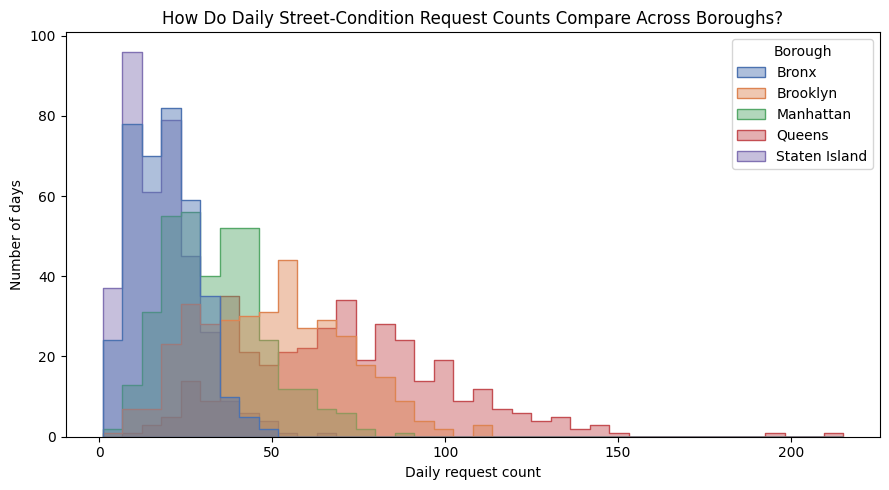

In [12]:
plt.figure(figsize=(9, 5))
ax = sns.histplot(
    data=daily_requests,
    x="request_count",
    hue="borough",
    hue_order=borough_order,
    element="step",
    multiple="layer",
    alpha=0.45,
    palette="deep"
)
ax.set_title("How Do Daily Street-Condition Request Counts Compare Across Boroughs?")
ax.set_xlabel("Daily request count")
ax.set_ylabel("Number of days")
legend = ax.get_legend()
legend.set_title("Borough")
plt.tight_layout()
plt.show()


**What does the histogram reveal, and what makes the boroughs easy or difficult to compare?**

Your answer: The histogram shows that Queens' distribution is shifted furthest to the right (higher typical daily counts) and is more spread out, while Staten Island and the Bronx cluster at the low end with narrower spreads. Brooklyn and Manhattan fall in between. The boroughs are somewhat difficult to compare directly because the five step outlines overlap heavily in the middle of the chart, making it hard to see each borough's individual shape or to precisely compare their centers and spreads at a glance.


### Create a box plot

Put `request_count` on the x-axis and `borough` on the y-axis. Use `borough_order`, the named color `"mediumseagreen"`, and descriptive labels.


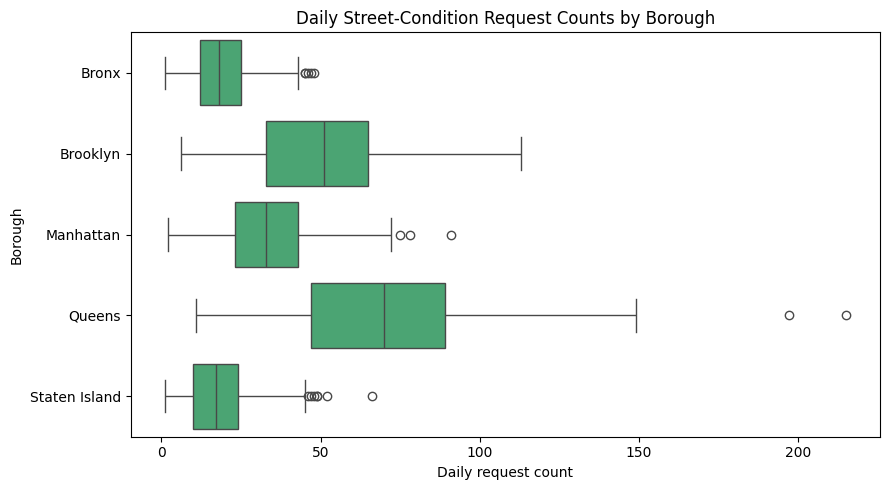

In [13]:
plt.figure(figsize=(9, 5))
ax = sns.boxplot(
    data=daily_requests,
    x="request_count",
    y="borough",
    order=borough_order,
    color="mediumseagreen"
)
ax.set_title("Daily Street-Condition Request Counts by Borough")
ax.set_xlabel("Daily request count")
ax.set_ylabel("Borough")
plt.tight_layout()
plt.show()


**What differences among boroughs are easier to see in the box plot than in the histogram?**

Your answer: The box plot lines up all five boroughs along the same axis, so it's much easier to directly compare their medians, interquartile ranges, and outliers side by side. It's immediately clear that Queens has both the highest median and the widest spread, that the Bronx and Staten Island have the lowest medians and are the most tightly clustered, and it flags individual high-count outlier days with separate points, which was hard to pick out in the overlapping histogram.


### Create a violin plot

Use the same x feature, y feature, and order. Change only the plot color to `"mediumpurple"` in addition to the required data mappings and order.


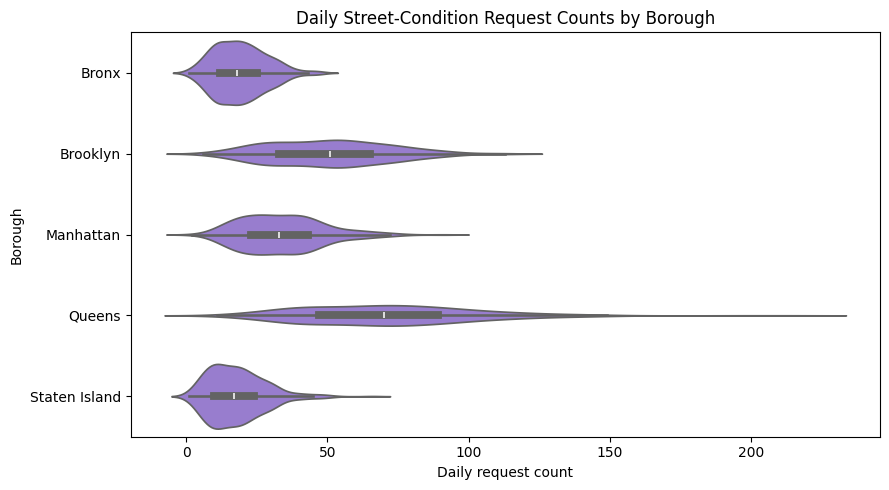

In [14]:
plt.figure(figsize=(9, 5))
ax = sns.violinplot(
    data=daily_requests,
    x="request_count",
    y="borough",
    order=borough_order,
    color="mediumpurple"
)
ax.set_title("Daily Street-Condition Request Counts by Borough")
ax.set_xlabel("Daily request count")
ax.set_ylabel("Borough")
plt.tight_layout()
plt.show()


**What does the violin plot add to the comparison?**

Your answer: The violin plot adds a view of the full shape of each borough's distribution, not just its five-number summary. It shows, for example, whether a borough's daily counts cluster tightly around one typical value or are spread across a wider, possibly multi-peaked range. This makes it easier to notice skew or unusual bumps in a distribution that the box plot's simpler summary can hide.


**Which of the three figures most clearly compares daily request counts among boroughs? Explain your choice.**

Your answer: The box plot most clearly compares daily request counts among boroughs. It shows the median, interquartile range, overall spread, and outliers for all five boroughs on one shared, easy-to-read axis, which makes ranking the boroughs and judging how much their typical values differ straightforward. The histogram is harder to read because the five distributions overlap, and the violin plot's extra shape detail is useful but slightly harder to compare at a glance than the box plot's compact summary.


## Step 6: Conclusion


**What conclusion about borough differences is supported by the 2025 data?**

Your answer: In 2025, Queens had the greatest typical daily volume of reported street-condition requests (a mean of about 71 per day), clearly higher than Brooklyn (about 50), Manhattan (about 34), the Bronx (about 19), and Staten Island (about 18). Queens also showed the widest day-to-day spread, meaning its daily counts varied the most. The Bronx and Staten Island consistently had the fewest and least variable daily requests.


## Step 7: Limitation


**Why do these request counts not directly measure the number of street problems or borough performance?**

Your answer: A 311 request count reflects how many times residents chose to report a street condition, not how many street problems actually exist. It can be influenced by borough population, total street mileage, construction activity, how aware residents are of 311, how easy it is for them to access the service, and how willing they are to report an issue in the first place. Two boroughs with the same number of actual street problems could show very different request counts if their residents differ in reporting behavior, so these counts describe reported demand, not the underlying condition of the streets or how well a borough's government is maintaining them.


# Your own analysis

Develop a new research question using the 311 data. Your question must compare a **quantitative feature across categorical groups**. You will probably need to calculate the quantitative feature from the original request records.

Possible grouping features include `descriptor`, month, or day of the week. You may use another meaningful categorical feature that you can create and explain.


## Step 1: Question


**Write a research question that compares a quantitative feature across categorical groups.**

Your answer: How does the total daily number of citywide street-condition requests differ across months of the year in 2025?


## Step 2: Data


**Which original features will you use, and what will each row of your calculated DataFrame represent?**

Your answer: I will use `created_date` from the original `requests` DataFrame. I'll normalize it to a calendar date and extract the month name from that date. Each row of my calculated DataFrame will represent the total citywide street-condition request count (summed across all five boroughs) for one calendar date, along with the month that date falls in.


## Step 3: Operation

Prepare the grouping feature, calculate the quantitative feature, and save the resulting DataFrame with a meaningful name.


In [15]:
daily_totals = requests.groupby("date").size().reset_index(name="request_count")

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
daily_totals["month"] = pd.Categorical(
    daily_totals["date"].dt.month_name(),
    categories=month_order,
    ordered=True
)

daily_totals.head()


,date,request_count,month
0,2025-01-01,189,January
1,2025-01-02,240,January
2,2025-01-03,136,January
3,2025-01-04,110,January
4,2025-01-05,155,January


**Briefly explain how your code produced the quantitative feature and comparison groups.**

Your answer: I grouped the original `requests` DataFrame by `date` and used `.size()` to count how many requests occurred on each calendar date across the whole city, then used `.reset_index(name="request_count")` to turn that into a `request_count` column this is my quantitative feature. I then used `.dt.month_name()` on each date to create a `month` category, and stored the months in calendar order as a `Categorical` type so charts and summaries display January through December in the correct order instead of alphabetically.


## Step 4: Check

Check the calculated data for missing or impossible values, confirm that the intended groups are present, and use an appropriate numerical summary to inspect the distributions.


In [16]:
print(daily_totals[["date", "request_count", "month"]].isnull().sum())
print()
print(daily_totals.groupby("month").size())
print()
daily_totals.groupby("month")["request_count"].describe()


date             0
request_count    0
month            0
dtype: int64

month
January      31
February     28
March        31
April        30
May          31
June         30
July         31
August       31
September    30
October      31
November     30
December     31
dtype: int64



,count,mean,std,min,25%,50%,75%,max
month,,,,,,,,
January,31.0,176.322581,64.229478,57.0,126.00,187.0,229.00,289.0
February,28.0,200.535714,71.319044,95.0,149.00,189.0,258.00,362.0
March,31.0,226.258065,68.748318,118.0,151.00,239.0,279.00,328.0
April,30.0,221.666667,58.439083,114.0,171.25,245.0,272.75,289.0
May,31.0,239.903226,81.063907,124.0,164.50,257.0,301.00,426.0
June,30.0,241.066667,76.516815,109.0,161.25,266.5,303.25,348.0
July,31.0,197.290323,66.355203,63.0,136.00,213.0,244.50,301.0
August,31.0,180.161290,52.436690,72.0,136.50,201.0,213.50,294.0
September,30.0,179.900000,59.527073,81.0,114.50,193.0,223.50,266.0


**What did your checks establish?**

Your answer: There are no missing values in `date`, `request_count`, or `month`. Every month has the expected number of days (28-31, matching the 2025 calendar), confirming no dates were dropped or duplicated. The `.describe()` summary shows all `request_count` minimums are positive, so there are no impossible negative or zero-request days, and each month has a distinct range of typical daily counts to compare.


## Step 5: Evidence

Create a histogram, box plot, or violin plot that directly addresses your question. Include a clear title and descriptive axis labels.


/tmp/ipykernel_106/1117349978.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


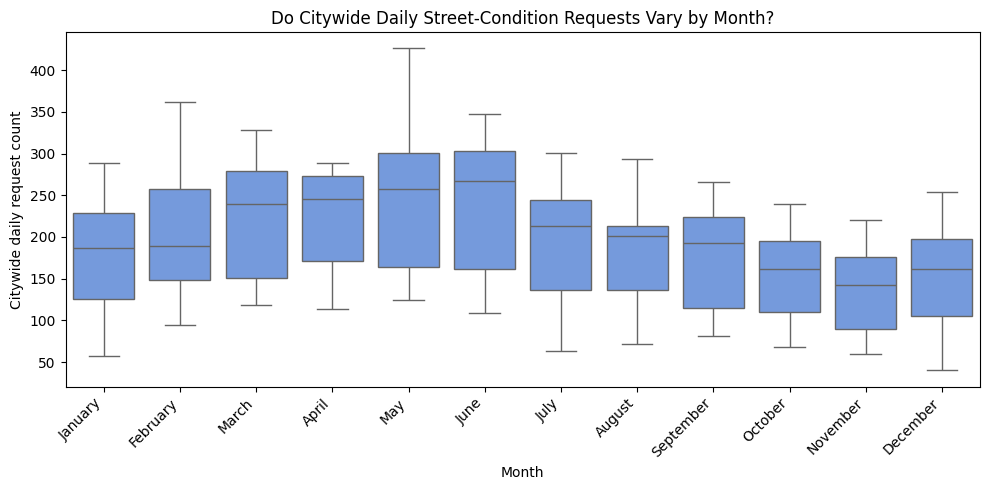

In [17]:
plt.figure(figsize=(10, 5))
ax = sns.boxplot(
    data=daily_totals,
    x="month",
    y="request_count",
    order=month_order,
    color="cornflowerblue"
)
ax.set_title("Do Citywide Daily Street-Condition Requests Vary by Month?")
ax.set_xlabel("Month")
ax.set_ylabel("Citywide daily request count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()


**What pattern in the figure provides the strongest evidence for your answer?**

Your answer: The box plot shows medians that rise from winter into a clear peak around May and June, then decline through the fall back down to the lowest medians in November and December. The boxes (interquartile ranges) for the summer months sit noticeably higher than the boxes for January, November, and December, with little overlap between the highest and lowest months, which is strong evidence that citywide daily request volume is higher in late spring/summer and lower in late fall/winter.


## Step 6: Conclusion


**State one conclusion that directly answers your research question.**

Your answer: The total daily number of citywide street-condition requests in 2025 was not constant throughout the year; it was highest in the late spring and summer months (May and June had the highest medians) and lowest in the late fall and winter months (November and December had the lowest medians).


## Step 7: Limitation


**State one important limitation on how your result should be interpreted.**

Your answer: This pattern describes when residents reported problems, not necessarily when street damage actually occurred or worsened. Seasonal factors like weather-driven road damage (e.g., winter freeze-thaw cycles creating potholes that aren't reported or fixed until warmer months), construction schedules, and even residents' willingness to go outside and notice or report problems in different weather could all shift the reporting pattern without a matching shift in the underlying number of street problems.


## AI-use reflection


State whether you used an AI tool. If you did, identify one suggestion you checked and explain what you accepted, modified, or rejected. If you did not, state that clearly.

Your answer: For this assignment I used Claude and Google to learn what a violin plot is and how to make one.

## Submission checklist

- Run every code cell from top to bottom.
- Use all requested object and feature names.
- Complete every written-response cell.
- Check that numerical claims match the output.
- Use named colors and audience-friendly labels.
- Compare center, spread, shape, overlap, and unusual values.
- Distinguish reported request volume from actual street conditions or city performance.
- Complete the AI-use reflection.
